<center><h1>Park_Peter_HW2</h1></center>
<br>
<br>

Name: Peter Park
<br>
Github Username: pspark1052
<br>
USC ID: 4240400712

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import MinMaxScaler

Get the Cycle Power Plant Data Set

In [2]:
df = pd.read_excel('Folds5x2_pp.xlsx', sheet_name='Sheet1')
df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


### (b) Exploring the data

#### i. rows and columns

In [3]:
df.shape

(9568, 5)

There are 9568 rows, 5 columns

Each row represents one hour of plant running at full load

Columns are 4 ambient predictors and 1 response.

AT is ambient temp in celsius

V is exhaust vacuum in cm Hg

AP is ambient pressure in millibar

RH is relative humidity in %

PE is net hourly electrical energy output in MW (response)

#### ii. pairwise scatterplots of all the varianbles

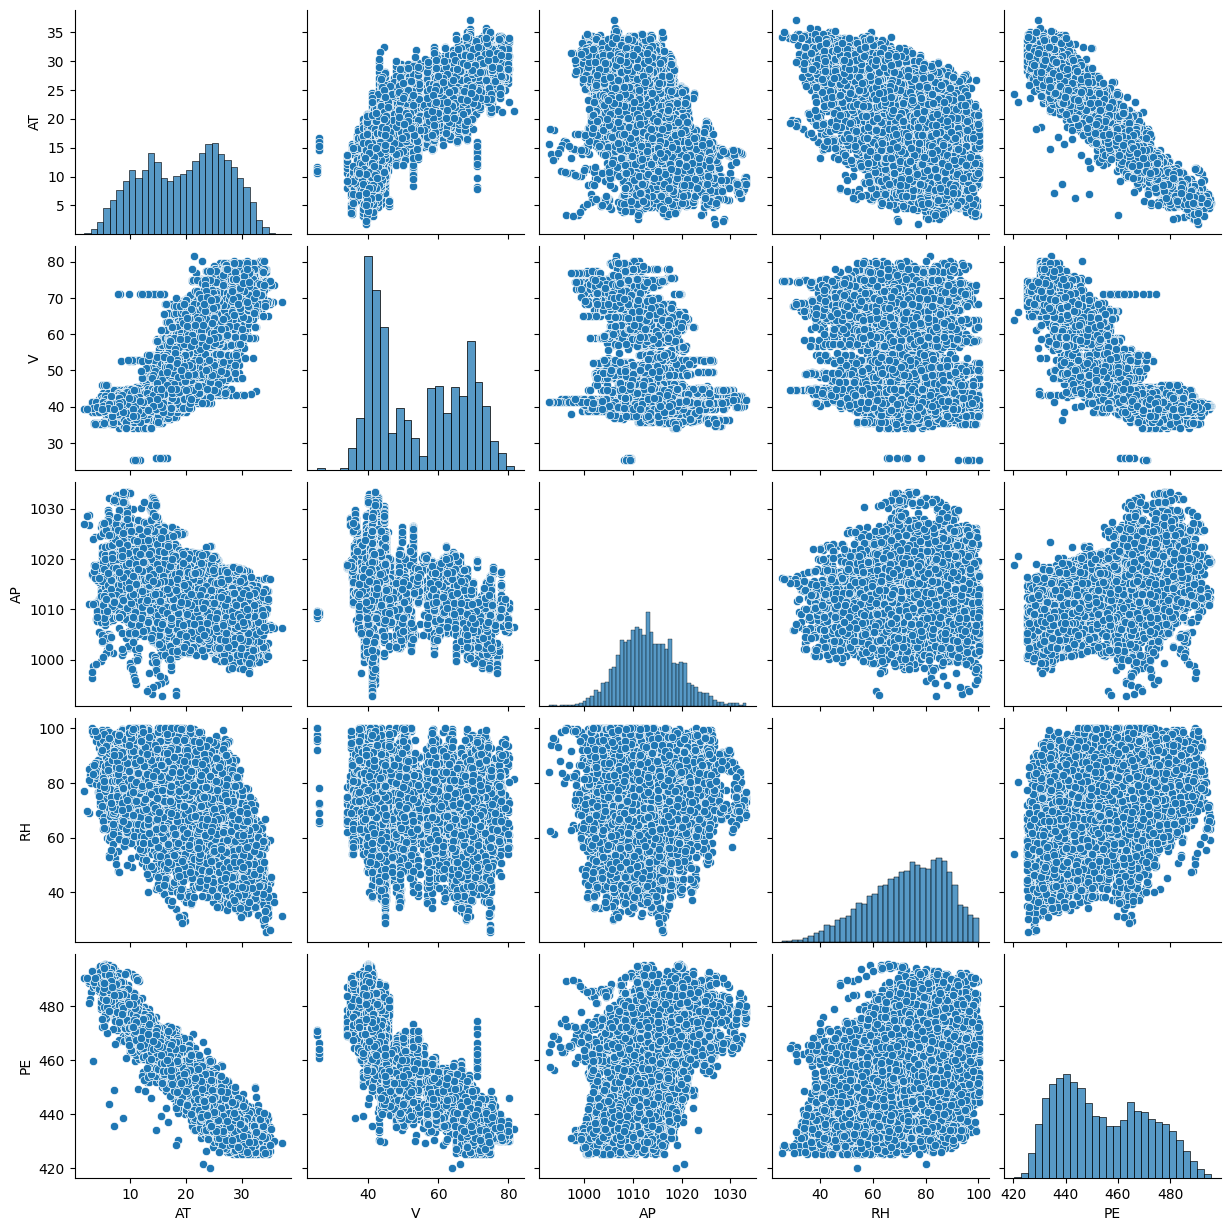

In [4]:
sns.pairplot(df)
plt.show()

Findings:

As AT increases, PE decreases. The points form a very tight band, so this is the strongest relationship. It looks roughly linear.

As V increases, PE decreases. This is also strong, but more spread out than AT. It looks somewhat curved.

As AP increases, PE increases, but the relationship is weak. The points form a wide cloud with no clear shape.

As RH increases, PE increases slightly. This is the weakest relationship, and there is no clear shape.

AT and V increase together, so these two predictors are strongly related to each other.

#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [5]:
summary = pd.DataFrame({
    'Mean':   df.mean(),
    'Median': df.median(),
    'Range':  df.max() - df.min(),
    'Q1':     df.quantile(0.25),
    'Q3':     df.quantile(0.75),
    'IQR':    df.quantile(0.75) - df.quantile(0.25),
})
summary.round(2)

,Mean,Median,Range,Q1,Q3,IQR
AT,19.65,20.34,35.30,13.51,25.72,12.21
V,54.31,52.08,56.20,41.74,66.54,24.80
AP,1013.26,1012.94,40.41,1009.10,1017.26,8.16
RH,73.31,74.97,74.60,63.33,84.83,21.50
PE,454.37,451.55,75.50,439.75,468.43,28.68


### (c) Simple Linear Regression

In [6]:
model_AT = smf.ols('PE ~ AT', data=df).fit()
print(model_AT.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                 8.510e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:26:28   Log-Likelihood:                -29756.
No. Observations:                9568   AIC:                         5.952e+04
Df Residuals:                    9566   BIC:                         5.953e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    497.0341      0.156   3177.280      0.0

In [7]:
predictors = ['AT', 'V', 'AP', 'RH']
models = {}

for x in predictors:
    models[x] = smf.ols(f'PE ~ {x}', data=df).fit()
    print(x)
    print('  coef:', round(models[x].params[x], 4))
    print('  p-value:', models[x].pvalues[x])
    print('  R-squared:', round(models[x].rsquared, 4))

AT
  coef: -2.1713
  p-value: 0.0
  R-squared: 0.8989
V
  coef: -1.1681
  p-value: 0.0
  R-squared: 0.7565
AP
  coef: 1.4899
  p-value: 0.0
  R-squared: 0.2688
RH
  coef: 0.4557
  p-value: 0.0
  R-squared: 0.1519


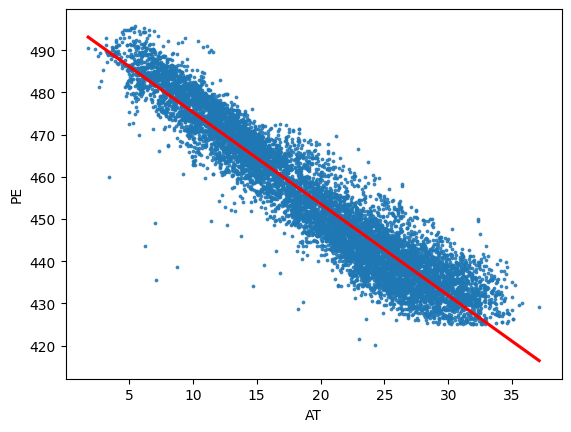

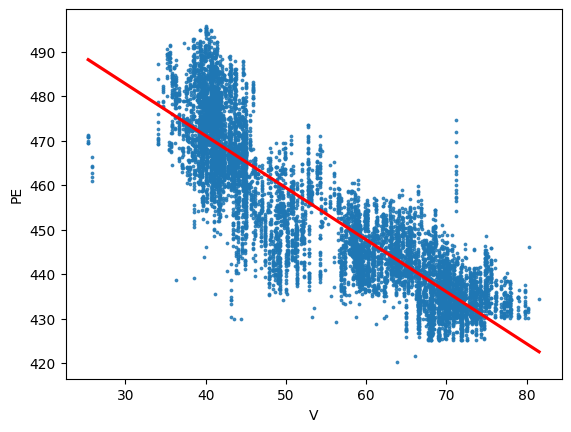

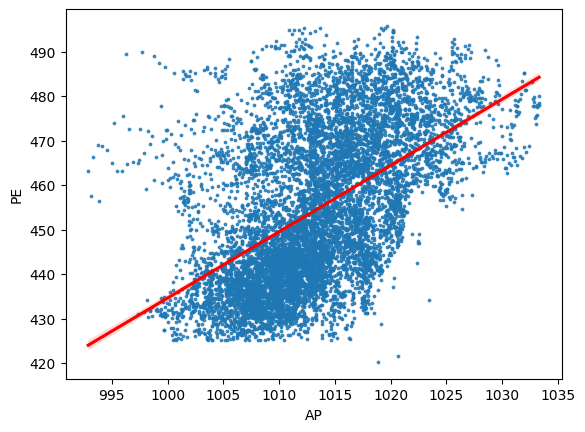

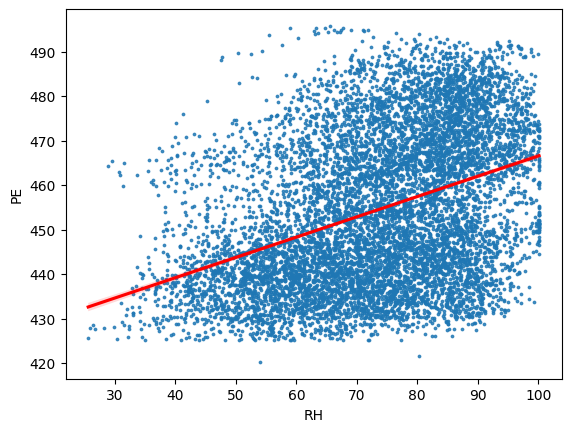

In [8]:
for x in predictors:
    sns.regplot(x=x, y='PE', data=df, scatter_kws={'s': 3}, line_kws={'color': 'red'})
    plt.show()

In [9]:
for x in predictors:
    resid = models[x].get_influence().resid_studentized_external
    print(x, 'outliers:', (abs(resid) > 3).sum())

AT outliers: 42
V outliers: 33
AP outliers: 30
RH outliers: 2


All four predictors are statistically significant, meaning p-value ≈ 0 < 0.05.

AT: coef -2.17, R-squared 0.90. Strongest. Points fit the line tightly.
V: coef -1.17, R-squared 0.76. Strong, but more spread out than AT.
AP: coef 1.49, R-squared 0.27. Weak. Points are widely spread.
RH: coef 0.46, RR-squared 0.15. Weakest. Points are very spread out.

AT and V lower PE, while AP and RH raise it.

Outliers (studentized residual > 3): AT 42, V 33, AP 30, RH 2. I would not remove them because they are less than 0.5% of the data, are real measurements, and barely affect the fit.

### (d) Multiple Regression

In [10]:
multi = smf.ols('PE ~ AT + V + AP + RH', data=df).fit()
print(multi.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:26:47   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    454.6093      9.749     46.634      0.0

R-squared = 0.929, so all four predictors together explain about 93% of PE.

Coefficients: AT -1.98, V -0.23, AP 0.06, RH -0.16. With the other predictors held fixed, AT, V, and RH lower PE, and AP slightly raises it.

All four p-values are about 0 (less than 0.05), so we reject the null hypothesis (coefficient = 0) for AT, V, AP, and RH.

### (e) 1c Compare to 1d

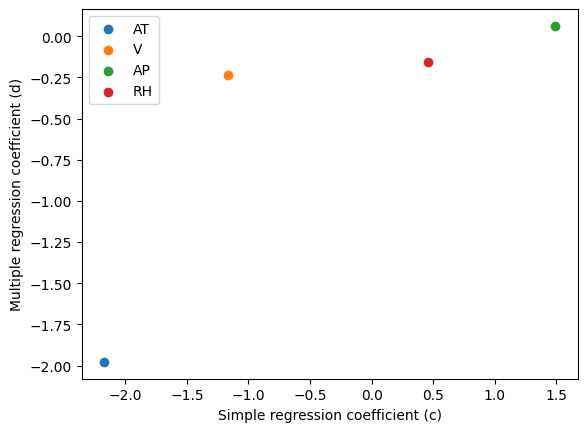

In [11]:
for x in predictors:
    plt.scatter(models[x].params[x], multi.params[x], label=x)

plt.xlabel('Simple regression coefficient (c)')
plt.ylabel('Multiple regression coefficient (d)')
plt.legend()
plt.show()

AT barely changes (-2.17 to -1.98).

V (-1.17 to -0.23) and AP (1.49 to 0.06) shrink a lot. RH changes sign (0.46 to -0.16).

This happens because the predictors are related to each other, especially AT and V. Alone, each predictor takes credit for some of AT's effect. Together, each one only shows its own effect.

### (f) Nonlinear Association

In [12]:
for x in predictors:
    X = df[x] - df[x].mean()
    m = smf.ols('PE ~ X + I(X**2) + I(X**3)', data=df).fit()
    print(x, m.pvalues[1:].round(4).tolist())

AT [0.0, 0.0, 0.0]
V [0.0, 0.0, 0.0137]
AP [0.0, 0.0, 0.0]
RH [0.0, 0.1014, 0.0]


Yes. All four predictors have at least one significant nonlinear term (p-value less than 0.05). The only non-significant term is RH squared (p = 0.10).

Predictors were centered first because AP cubed is too large to compute reliably.

### (g) Interactions of Predictors

In [13]:
inter = smf.ols('PE ~ (AT + V + AP + RH)**2', data=df).fit()
print(inter.pvalues.round(4))

Intercept    0.0000
AT           0.0670
V            0.0000
AP           0.0474
RH           0.0423
AT:V         0.0000
AT:AP        0.4521
AT:RH        0.0000
V:AP         0.0000
V:RH         0.0862
AP:RH        0.0336
dtype: float64


Yes. Four interaction terms are significant (p-value less than 0.05): AT:V, AT:RH, V:AP, and AP:RH.

AT:AP (p = 0.45) and V:RH (p = 0.09) are not significant.

### (h) Improvement

In [14]:
train, test = train_test_split(df, test_size=0.3, random_state=42)

lin = smf.ols('PE ~ AT + V + AP + RH', data=train).fit()
print('Train MSE:', ((train['PE'] - lin.predict(train))**2).mean())
print('Test MSE:', ((test['PE'] - lin.predict(test))**2).mean())

Train MSE: 20.58083972573869
Test MSE: 21.239856938225493


In [15]:
big = smf.ols('PE ~ AT + V + AP + RH + AT:V + AT:AP + AT:RH + AP:RH + I(AT**2) + I(AP**2) + I(RH**2)', data=train).fit()
print(big.pvalues.round(4))
print('Train MSE:', ((train['PE'] - big.predict(train))**2).mean())
print('Test MSE:', ((test['PE'] - big.predict(test))**2).mean())

Intercept     0.0000
AT            0.0000
V             0.0000
AP            0.0000
RH            0.0001
AT:V          0.0000
AT:AP         0.0015
AT:RH         0.0000
AP:RH         0.0003
I(AT ** 2)    0.0000
I(AP ** 2)    0.0000
I(RH ** 2)    0.0000
dtype: float64
Train MSE: 17.890842773184925
Test MSE: 18.660040495060656


Yes, the model improves.

Linear model: train MSE 20.58, test MSE 21.24.
Model with interactions and squared terms: train MSE 17.89, test MSE 18.66.

Starting from all 4 predictors, 6 interactions, and 4 squared terms, I removed the least significant term one at a time: V:RH, then V^2, then V:AP. Main predictors were kept while they were part of an interaction. All remaining terms have p-value less than 0.05.

### (i) KNN

In [16]:
def knn_errors(X_train, X_test):
    train_err, test_err = [], []
    for k in range(1, 101):
        knn = KNeighborsRegressor(n_neighbors=k).fit(X_train, train['PE'])
        train_err.append(((train['PE'] - knn.predict(X_train))**2).mean())
        test_err.append(((test['PE'] - knn.predict(X_test))**2).mean())
    return train_err, test_err

raw_train, raw_test = knn_errors(train[predictors], test[predictors])
print('Raw: best k =', raw_test.index(min(raw_test)) + 1, ' test MSE =', min(raw_test))

scaler = MinMaxScaler().fit(train[predictors])
norm_train, norm_test = knn_errors(scaler.transform(train[predictors]), scaler.transform(test[predictors]))
print('Normalized: best k =', norm_test.index(min(norm_test)) + 1, ' test MSE =', min(norm_test))

Raw: best k = 5  test MSE = 15.726819842563568
Normalized: best k = 4  test MSE = 14.291333431295715


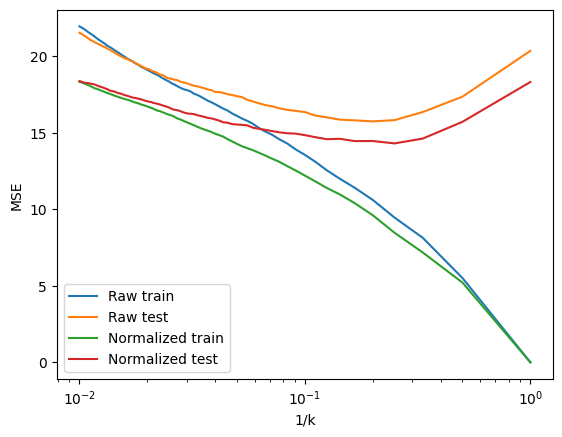

In [17]:
inv_k = [1/k for k in range(1, 101)]

plt.plot(inv_k, raw_train, label='Raw train')
plt.plot(inv_k, raw_test, label='Raw test')
plt.plot(inv_k, norm_train, label='Normalized train')
plt.plot(inv_k, norm_test, label='Normalized test')
plt.xscale('log')
plt.xlabel('1/k')
plt.ylabel('MSE')
plt.legend()
plt.show()

Raw: best k = 5, test MSE = 15.73.
Normalized: best k = 4, test MSE = 14.29.

Normalized features do better. Small k overfits: train error drops to 0, but test error goes up.

### (j ) Compare KNN and Linear

The best linear model (interactions and squared terms) has test MSE 18.66. The best KNN (normalized, k = 4) has test MSE 14.29, so KNN predicts better.

KNN works well here because there is a lot of data and only 4 predictors, so it can capture patterns the linear model misses.

Linear regression is easier to interpret, since it shows each predictor's effect on PE and whether it is significant.

## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.

Better. With lots of data, a flexible method can fit the true pattern closely without overfitting.

### (b) The number of predictors p is extremely large, and the number of observations n is small.

Worse. With few observations and many predictors, a flexible method will overfit the noise.

### (c) The relationship between the predictors and response is highly non-linear.

Better. An inflexible method can't capture a non-linear shape, but a flexible method can.

### (d) The variance of the error terms, i.e. $σ^2$ = Var(ε), is extremely high.

Worse. With a lot of noise, a flexible method will fit the noise and overfit.

## 3. ISLR: 2.4.7

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

Obs 1: sqrt(0 + 9 + 0) = 3

Obs 2: sqrt(4 + 0 + 0) = 2

Obs 3: sqrt(0 + 1 + 9) = 3.16

Obs 4: sqrt(0 + 1 + 4) = 2.24

Obs 5: sqrt(1 + 0 + 1) = 1.41

Obs 6: sqrt(1 + 1 + 1) = 1.73

### (b) What is our prediction with K = 1? Why?

Green. The nearest point is Obs 5 (distance 1.41), which is Green.

### (c) What is our prediction with K = 3? Why?

Red. The 3 nearest points are Obs 5 (Green), Obs 6 (Red), and Obs 2 (Red). The majority is Red.

### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

Small. A small K is more flexible, so the boundary can bend to follow a non-linear shape. A large K smooths the boundary out.